In [2]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving loan_approval.xlsx to loan_approval.xlsx


In [4]:
df = pd.read_excel('/content/loan_approval.xlsx')

In [5]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [6]:
df.shape

(2000, 8)

In [7]:
df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


In [8]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [9]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['name', 'city'], dtype='object')


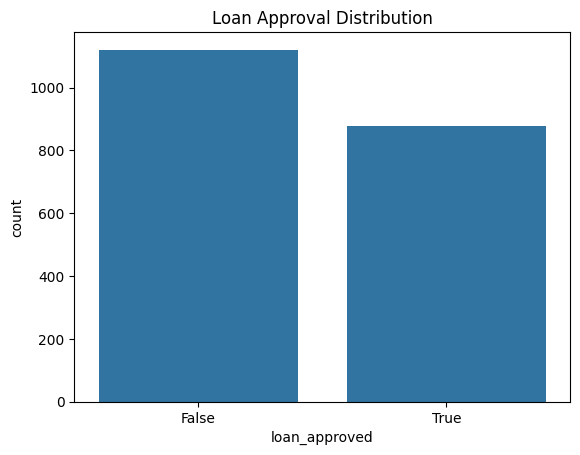

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)

plt.title('Loan Approval Distribution')
plt.show()

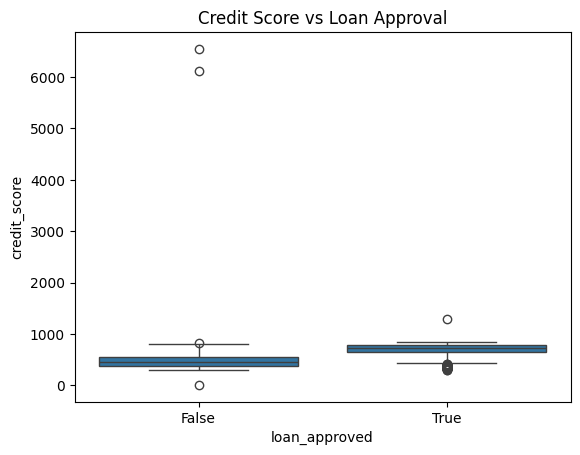

In [11]:
sns.boxplot(x='loan_approved',
            y='credit_score',
            data=df)

plt.title('Credit Score vs Loan Approval')
plt.show()

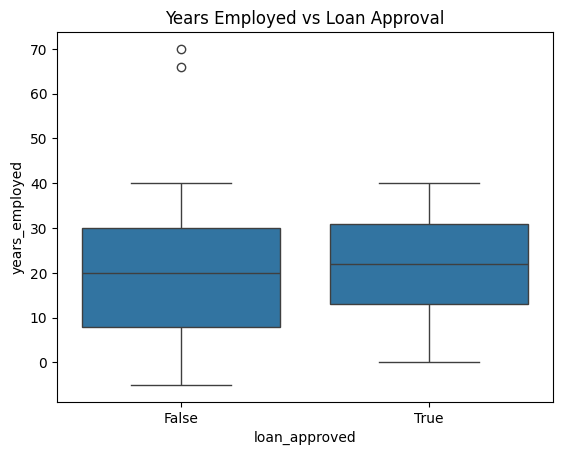

In [12]:
sns.boxplot(x='loan_approved',
            y='years_employed',
            data=df)

plt.title('Years Employed vs Loan Approval')
plt.show()

In [13]:
num_cols = ['income',
            'credit_score',
            'loan_amount',
            'years_employed',
            'points']

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |
                  (df[col] > upper)]

    print(col, len(outliers))

income 0
credit_score 3
loan_amount 0
years_employed 2
points 0


In [14]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    print(f"\nColumn: {col}")
    print(f"Lower Limit: {lower}")
    print(f"Upper Limit: {upper}")

    # Count outliers before treatment
    outliers_before = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers Before Capping: {len(outliers_before)}")

    # Apply capping
    df[col] = df[col].clip(lower, upper)

    # Count outliers after treatment
    outliers_after = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers After Capping: {len(outliers_after)}")


Column: income
Lower Limit: -26909.0
Upper Limit: 208305.0
Outliers Before Capping: 0
Outliers After Capping: 0

Column: credit_score
Lower Limit: 8.5
Upper Limit: 1140.5
Outliers Before Capping: 3
Outliers After Capping: 0

Column: loan_amount
Lower Limit: -24198.875
Upper Limit: 74328.125
Outliers Before Capping: 0
Outliers After Capping: 0

Column: years_employed
Lower Limit: -21.5
Upper Limit: 62.5
Outliers Before Capping: 2
Outliers After Capping: 0

Column: points
Lower Limit: 7.5
Upper Limit: 107.5
Outliers Before Capping: 0
Outliers After Capping: 0


In [15]:
df['loan_approved'] = df['loan_approved'].astype(int)

df.drop(['name','city'],
        axis=1,
        inplace=True)

df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


In [18]:
X = df.drop('loan_approved', axis=1)

y = df['loan_approved']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2000, 5)
y Shape: (2000,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Set Shapes")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Set Shapes")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Training Set Shapes
X_train: (1600, 5)
y_train: (1600,)

Testing Set Shapes
X_test: (400, 5)
y_test: (400,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print first 5 rows of scaled training data
print("Scaled Training Data:")
print(X_train_scaled[:5])

print("\nScaled Testing Data:")
print(X_test_scaled[:5])

Scaled Training Data:
[[-1.1701829  -0.67555613 -0.21763755  0.28734102 -1.67529511]
 [-0.58084238 -0.40663018 -0.20015315 -1.31075028 -1.14503355]
 [-0.05506472  1.36583635 -0.53624989  0.03501082  1.50627424]
 [-0.57411799 -1.26841563 -0.85854316  0.70789136 -0.61477199]
 [ 0.18017296  1.15191797 -1.20334669 -1.22664021  1.50627424]]

Scaled Testing Data:
[[ 1.15775999 -0.77945934 -0.63535171 -0.89019994 -0.08451044]
 [-1.05201336  1.42695588 -1.07982336  0.03501082  1.50627424]
 [ 0.44007639  0.75464099  0.47409314  1.21255177  0.97601268]
 [-0.47212176  0.44904332 -1.33394873 -0.04909925  0.44575112]
 [-1.47782369  1.39028416 -0.92614475  0.79200143  0.7108819 ]]


In [22]:
print("Mean of scaled features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_train_scaled.std(axis=0))

Mean of scaled features:
[ 2.99760217e-17 -2.22044605e-18 -4.44089210e-17 -3.10862447e-17
 -5.55111512e-19]

Standard deviation of scaled features:
[1. 1. 1. 1. 1.]


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0
 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1]


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[217   0]
 [  0 183]]


In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

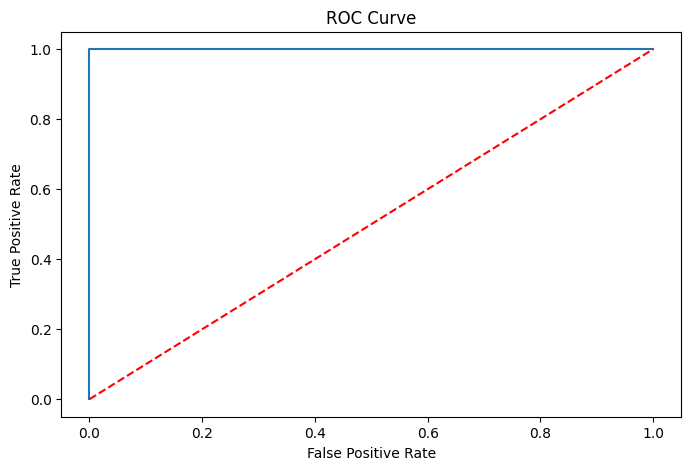

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test,
                                y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

In [29]:
auc = roc_auc_score(y_test,
                    y_prob)

print(auc)

1.0
